In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("song_recomendation_B.csv")
df


,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),Pitbull,Pitbull Starring In Rebelution,2009-10-23,64,"dance pop,miami hip hop,pop",0.825,0.743,2.0,-5.995,1.0,0.1490,0.014200,0.000021,0.2370,0.800,127.045,4.0
1,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,Britney Spears,...Baby One More Time (Digital Deluxe Version),1999-01-12,56,"dance pop,pop",0.677,0.665,7.0,-5.171,1.0,0.0305,0.560000,NaN,0.3380,0.706,74.981,4.0
2,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,1969-12-05,0,"album rock,british invasion,classic rock,rock",0.319,0.627,0.0,-9.611,1.0,0.0687,0.675000,0.000073,0.2890,0.497,85.818,4.0
3,spotify:track:4bEb3KE4mSKlTFjtWJQBqO,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,1977-02-04,79,"album rock,classic rock,rock,soft rock,yacht rock",0.671,0.710,9.0,-7.724,1.0,0.0356,0.039300,0.000011,0.0387,0.834,118.745,4.0
4,spotify:track:0d2iYfpKoM0QCKvcLCkBao,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),2018-07-12,78,"pop,electropop,etherpop,indie poptimism,pop,po...",0.560,0.680,6.0,-7.648,0.0,0.3210,0.555000,0.000000,0.1160,0.319,89.391,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,spotify:track:4gFL3QgCRx0o1B5KjlkCR1,Get A Life,Freestylers,Raw As F**k,2004-03-26,22,"big beat,breakbeat",0.710,0.952,11.0,-6.286,0.0,0.0557,0.023200,0.000121,0.2860,0.889,137.976,4.0
4995,spotify:track:3AjSfp5FDvwtMU9XBsbS8j,Push Up - Main Edit,Creeds,Push Up (Main Edit),2023-03-31,86,NaN,0.767,0.830,7.0,-8.780,1.0,0.2060,0.209000,0.836000,0.0582,0.187,75.023,4.0
4996,spotify:track:6PUzxtIHkv346yP89NzP9X,Kernkraft 400,Zombie Nation,Kernkraft 400 Single Mixes,2006-03-07,57,german techno,0.798,0.430,8.0,-7.839,0.0,0.0868,0.005500,0.901000,0.1460,0.487,140.064,4.0
4997,spotify:track:3kcKlOkQQEPVwxwljbGJ5p,Kernkraft 400 (A Better Day),"Topic, A7S",Kernkraft 400 (A Better Day),2022-06-17,79,"german dance,pop dance,pop edm,uk dance,pop da...",0.623,0.727,11.0,-5.570,0.0,0.0562,0.184000,0.000020,0.3090,0.400,125.975,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4999 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  4997 non-null   object 
 5   Popularity          4999 non-null   int64  
 6   Artist Genres       4744 non-null   object 
 7   Danceability        4747 non-null   float64
 8   Energy              4997 non-null   float64
 9   Key                 4997 non-null   float64
 10  Loudness            4997 non-null   float64
 11  Mode                4997 non-null   float64
 12  Speechiness         4997 non-null   float64
 13  Acousticness        4997 non-null   float64
 14  Instrumentalness    4897 non-null   float64
 15  Liveness            4997 non-null   float64
 16  Valenc

In [ ]:
null_percent = (df.isna().mean() * 100).sort_values(ascending=False)
null_percent = null_percent[null_percent > 0]

print(null_percent)


Artist Genres         5.101020
Danceability          5.041008
Instrumentalness      2.040408
Liveness              0.040008
Valence               0.040008
Speechiness           0.040008
Energy                0.040008
Key                   0.040008
Loudness              0.040008
Mode                  0.040008
Album Release Date    0.040008
Tempo                 0.040008
Time Signature        0.040008
Acousticness          0.040008
dtype: float64


In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [ ]:
df = df.dropna(subset=["Album Release Date"])
df = df.dropna(subset=["Artist Genres"])


In [ ]:
df.duplicated().sum()


np.int64(13)

In [ ]:
df = df.drop_duplicates()


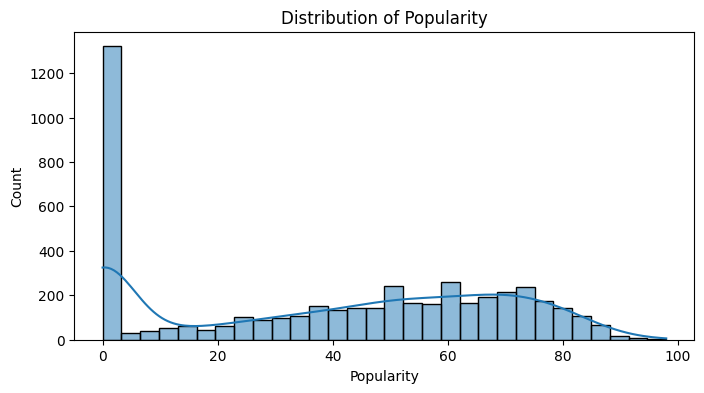

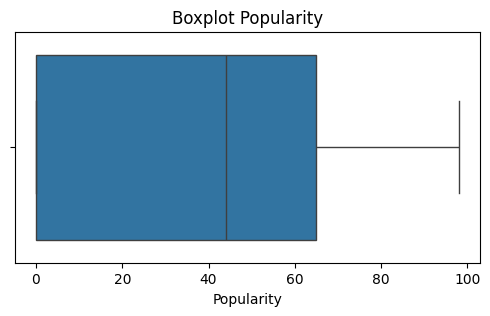

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
sns.histplot(df["Popularity"], bins=30, kde=True)
plt.title("Distribution of Popularity")
plt.show()

plt.figure(figsize=(6,3))
sns.boxplot(x=df["Popularity"])
plt.title("Boxplot Popularity")
plt.show()


The **Popularity** feature shows a **highly skewed distribution**. The histogram indicates a **very large concentration of values near 0**, suggesting many items have extremely low popularity (possibly “unpopular”). After that spike, the values spread widely from around 10 up to nearly 100, with a visible rise in frequency between roughly **50–80**, meaning a substantial portion of the data falls into a moderate-to-high popularity range. The boxplot supports this pattern: the **median is around the mid-range (≈45–50)** and the spread is wide, indicating strong variability across items. Overall, the feature contains **many low-end values combined with a broad mid-to-high range**, which implies the dataset includes both a large group of very unpopular items and another group with relatively strong popularity.


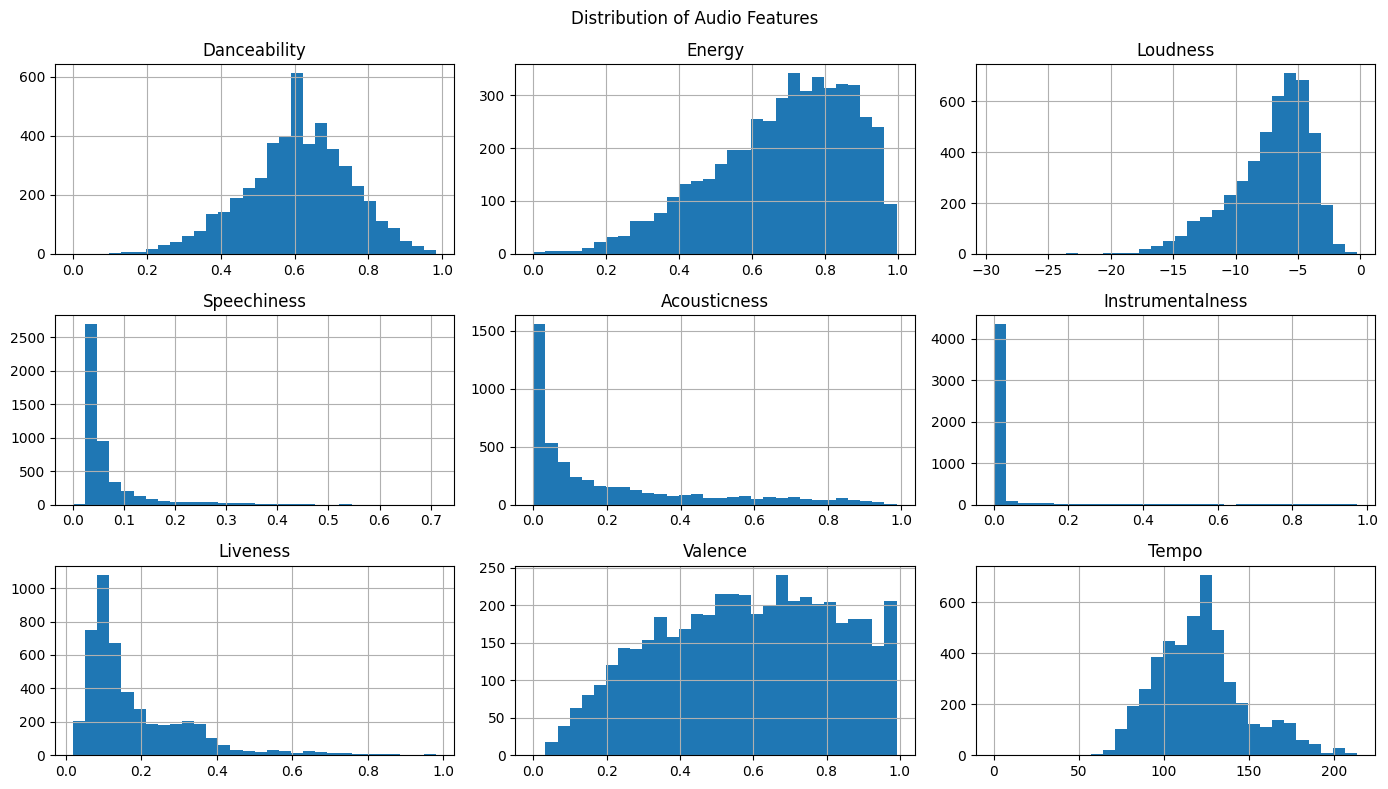

In [ ]:
audio_cols = ["Danceability","Energy","Loudness","Speechiness","Acousticness",
              "Instrumentalness","Liveness","Valence","Tempo"]

audio_cols = [c for c in audio_cols if c in df.columns]

df[audio_cols].hist(figsize=(14,8), bins=30)
plt.suptitle("Distribution of Audio Features")
plt.tight_layout()
plt.show()


Overall, the audio features show clear patterns that describe the general “sound profile” of the tracks in the dataset. **Danceability** is mostly concentrated around the mid-to-high range (roughly 0.5–0.75), suggesting many songs are fairly rhythm-friendly and suitable for casual listening or upbeat playlists. **Energy** is also skewed toward higher values (around 0.6–0.9), indicating that the dataset contains a large number of energetic and intense tracks rather than calm or slow ones. **Loudness** is strongly centered around typical modern music levels (approximately -10 to -3 dB), meaning most tracks are relatively loud and professionally mastered. On the other hand, **Speechiness**, **Instrumentalness**, and **Acousticness** are heavily right-skewed with most values near zero, implying that the majority of songs are not speech-dominant. **Liveness** is also mostly low, which suggests most songs sound like studio recordings rather than live performances. **Valence** shows a broader spread across mid to high values, meaning the emotional tone varies but generally trends toward more positive or “happy” moods. Lastly, **Tempo** forms a clear peak around the common pop range (roughly 100–140 BPM), showing that most tracks follow mainstream tempo patterns with fewer extremely slow or extremely fast songs.



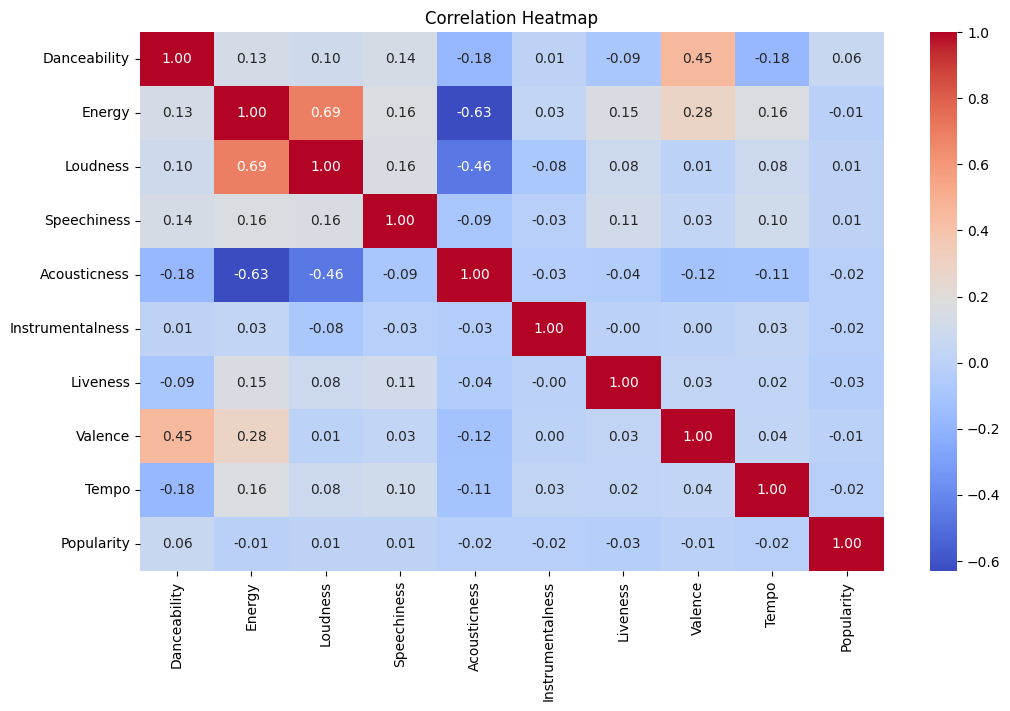

In [ ]:
plt.figure(figsize=(12,7))
sns.heatmap(df[audio_cols + ["Popularity"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



1) **Energy and Loudness show a strong positive relationship (≈ 0.69).**
   This indicates that tracks with higher energy levels tend to be louder, which is expected since energetic songs are usually produced with higher intensity.

2) **Acousticness is strongly negatively correlated with Energy (≈ -0.63).**
   This suggests that more acoustic songs generally have lower energy, while high-energy tracks are less acoustic and more heavily produced or electronic.

3) **Acousticness also has a negative correlation with Loudness (≈ -0.46).**
   This means acoustic tracks tend to be quieter, whereas louder songs often contain stronger instrumentation or electronic elements.

4) **Danceability is moderately correlated with Valence (≈ 0.45).**
   This implies that more danceable songs tend to have a more positive or happy mood.

5) **Most other relationships between audio features are weak.**
   Features such as Speechiness, Instrumentalness, Liveness, and Tempo show low correlations with many other variables, meaning they capture different and more independent aspects of the music.

6) **Popularity is almost not correlated with the audio features.**
   Popularity values have correlations close to zero with most audio features, indicating that popularity is likely influenced by external factors such as artist fame, marketing, playlists, and social media trends rather than audio characteristics alone.


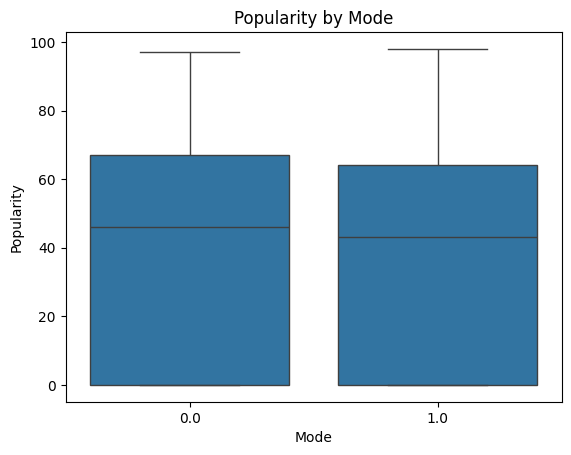

In [ ]:
if "Mode" in df.columns:
    sns.boxplot(data=df, x="Mode", y="Popularity")
    plt.title("Popularity by Mode")
    plt.show()


1) The **median popularity** for both modes is **very similar**, meaning songs in major and minor scales tend to achieve comparable popularity levels overall.
2) Both groups show a **wide spread** of popularity scores, indicating that songs from either mode can be either highly popular or less popular.
3) Since the distributions overlap heavily, **mode alone does not appear to be a strong factor** in determining a song’s popularity in this dataset.


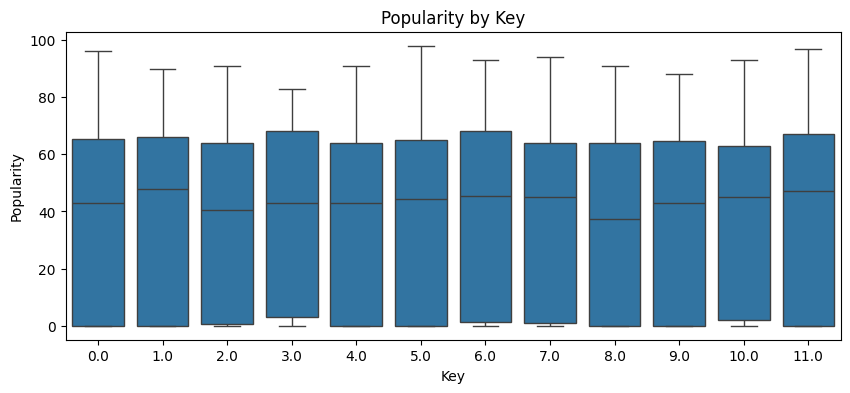

In [ ]:
if "Key" in df.columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=df, x="Key", y="Popularity")
    plt.title("Popularity by Key")
    plt.show()


1) The **median popularity values** across keys are generally **quite similar**, suggesting that no single musical key consistently produces more popular songs.
2) Most keys display a **wide spread** in popularity scores, meaning that songs in any key can range from low to very high popularity.
3) The boxplots overlap heavily across keys, indicating that **musical key is not a strong standalone factor** for explaining popularity differences in this dataset.



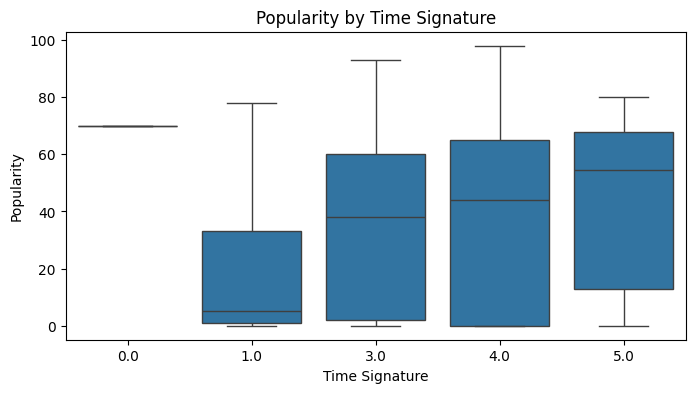

In [ ]:
if "Time Signature" in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x="Time Signature", y="Popularity")
    plt.title("Popularity by Time Signature")
    plt.show()


1) Songs with **Time Signature = 4** (commonly 4/4) appear to have a **higher median popularity** compared to several other time signatures.
2) **Time Signature = 5** also shows a relatively high median popularity in this dataset, but the distribution is wide and may depend on the number of songs available in that category.
3) Some categories (such as **Time Signature = 0 or 1**) may contain **very few tracks**, which can make the popularity distribution less reliable and harder to generalize.
4) Overall, there is noticeable variation across time signatures, but the **overlapping spreads** suggest that time signature alone is not enough to fully explain popularity differences.


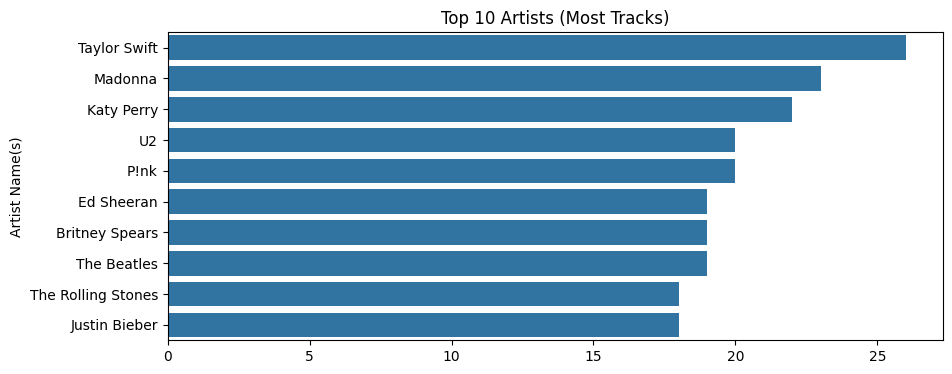

In [ ]:
if "Artist Name(s)" in df.columns:
    top_artists = df["Artist Name(s)"].value_counts().head(10)
    plt.figure(figsize=(10,4))
    sns.barplot(x=top_artists.values, y=top_artists.index)
    plt.title("Top 10 Artists (Most Tracks)")
    plt.show()


1) **Taylor Swift** has the highest number of tracks in the dataset, making her the most represented artist.
2) Other highly represented artists include **Madonna, Katy Perry, U2, P!nk, and Ed Sheeran**, indicating that the dataset contains many tracks from globally popular artists across different eras and genres.
3) The presence of legendary groups such as **The Beatles** and **The Rolling Stones** suggests that the dataset includes both modern and classic music.
4) The dataset is **not evenly distributed across artists**, meaning some artists contribute significantly more songs than others.



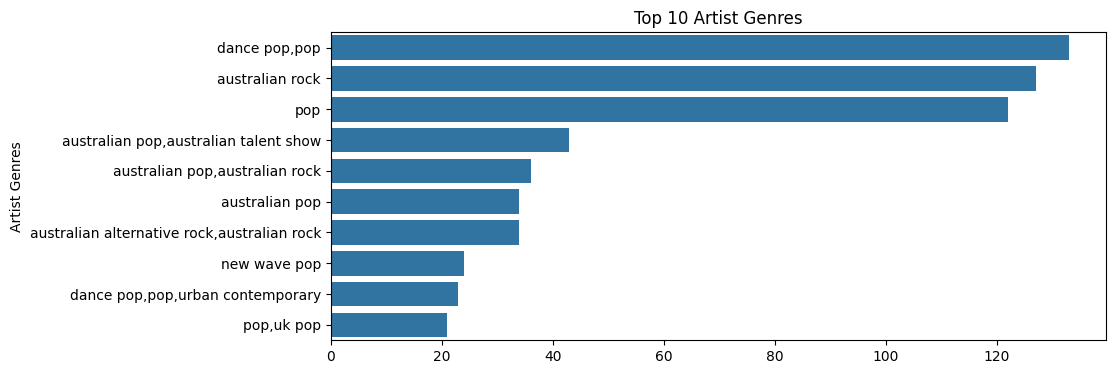

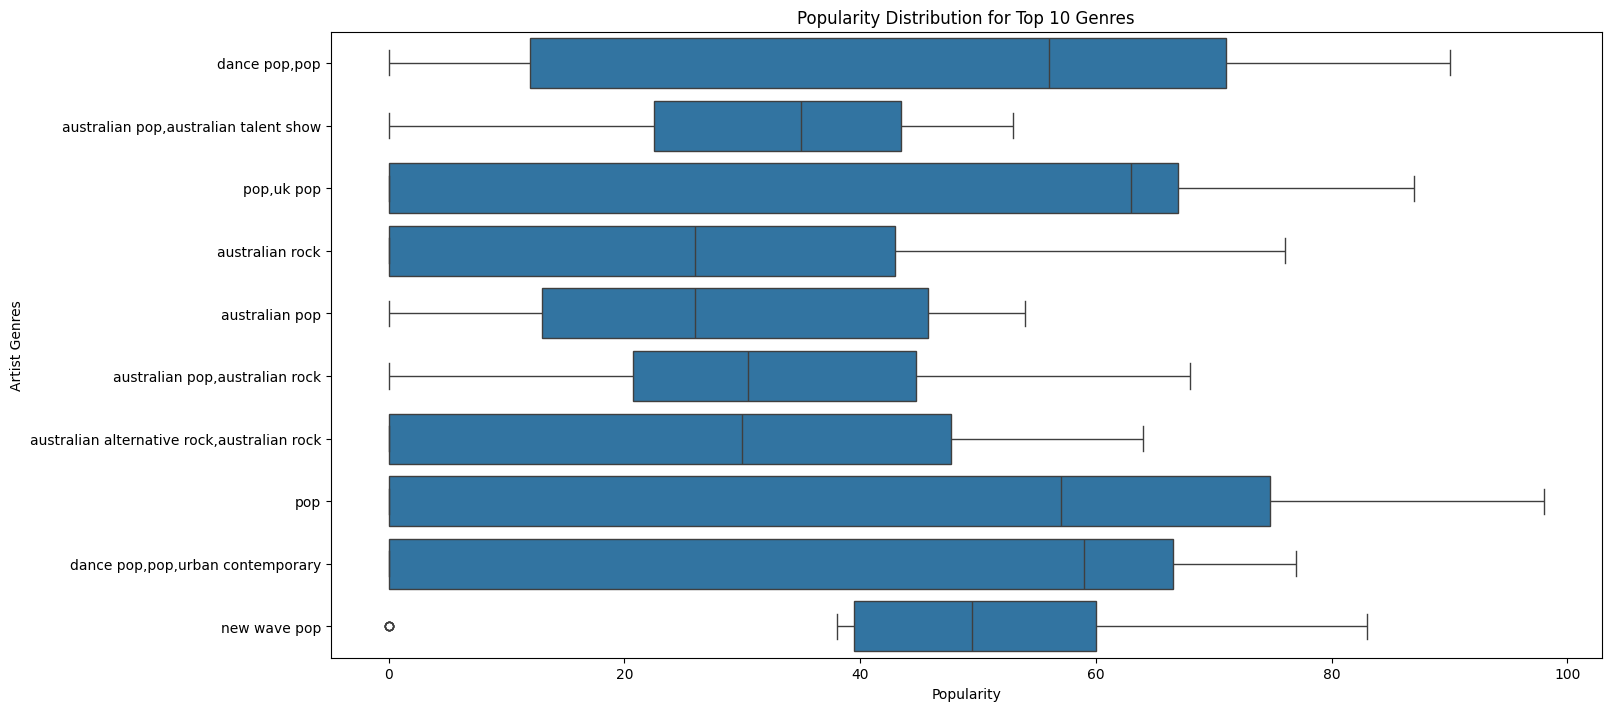

In [ ]:
if "Artist Genres" in df.columns:
    top_genres = df["Artist Genres"].value_counts().head(10)
    plt.figure(figsize=(10,4))
    sns.barplot(x=top_genres.values, y=top_genres.index)
    plt.title("Top 10 Artist Genres")
    plt.show()

    top_genres_list = top_genres.index.tolist()
    df_top = df[df["Artist Genres"].isin(top_genres_list)]

    plt.figure(figsize=(16, 7), constrained_layout=True)

    sns.boxplot(
        data=df_top,
        x="Popularity",
        y="Artist Genres"
    )

    plt.title("Popularity Distribution for Top 10 Genres")
    plt.xlabel("Popularity")
    plt.ylabel("Artist Genres")

    plt.show()





### Top 10 Artist Genres in the Dataset

1) The most common genres are strongly dominated by **pop-related categories**, such as:
   - **dance pop, pop**
   - **pop**
   - **new wave pop**
   - combinations like **pop, uk pop** and **dance pop, pop, urban contemporary**
   
   This suggests that the dataset contains a large number of tracks from mainstream pop music.

2) Several of the top genre labels include **Australian-related genres**, such as:
   - **australian rock**
   - **australian pop**
   - **australian pop, australian talent show**
   - **australian alternative rock, australian rock**
   
   This indicates that the dataset may include many artists or songs associated with the Australian music scene.





###Popularity Distribution for Top 10 Genres
1) The popularity scores vary widely across genres, indicating that **genre alone does not fully determine popularity**.
2) Several genres such as **'pop, uk pop'**, **'dance pop, pop'**, and **'pop'** show **higher median popularity**, suggesting that mainstream pop-related genres tend to perform well on average.
3) Genres like **'australian rock'** and **'australian pop'** show more moderate median popularity, with a relatively broad spread, meaning tracks in these genres can still achieve both low and high popularity.
4) Some genres display **large variability (wide IQR and long whiskers)**, which implies that popularity within the same genre can differ significantly depending on other factors (artist exposure, release timing, marketing, playlists, trends, etc.).
5) A few genres contain **outliers**, indicating the presence of tracks that are unusually less popular or exceptionally popular compared to the typical distribution of that genre.



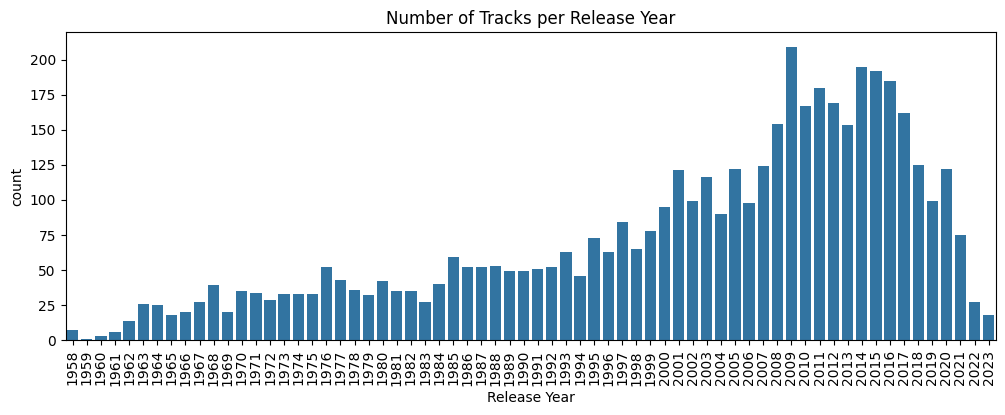

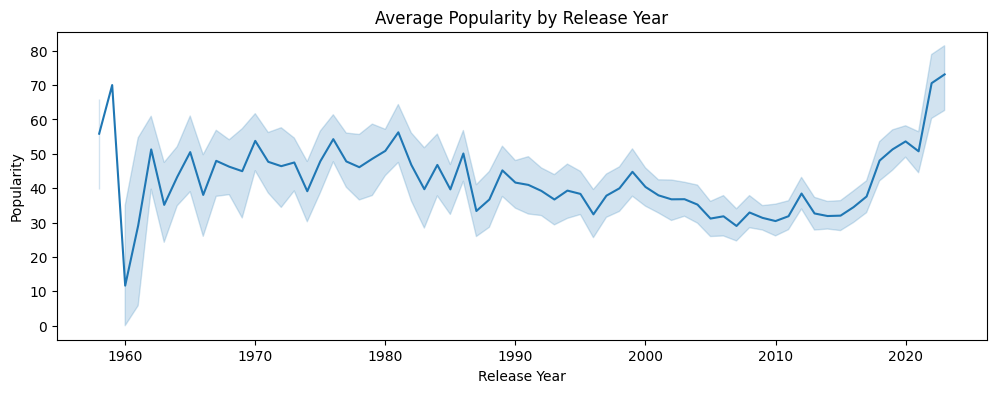

In [ ]:
if "Album Release Date" in df.columns:
    df["Album Release Date"] = pd.to_datetime(df["Album Release Date"], format='mixed')
    df["Release Year"] = df["Album Release Date"].dt.year

    plt.figure(figsize=(12,4))
    sns.countplot(data=df, x="Release Year", order=sorted(df["Release Year"].dropna().unique()))
    plt.xticks(rotation=90)
    plt.title("Number of Tracks per Release Year")
    plt.show()

    plt.figure(figsize=(12,4))
    sns.lineplot(data=df, x="Release Year", y="Popularity", estimator="mean")
    plt.title("Average Popularity by Release Year")
    plt.show()

### 1) Number of Tracks per Release Year
- The dataset contains relatively **fewer tracks in earlier decades** (e.g., before the 1980s), which may be due to limited availability or dataset coverage.
- The number of tracks increases gradually over time and becomes much higher from the **late 1990s to the 2010s**, suggesting that more recent music is more heavily represented.
- The highest concentration of tracks appears around the **late 2000s to mid-2010s**, indicating a strong dataset focus on modern releases.


### 2) Average Popularity by Release Year
- The average popularity shows noticeable fluctuations in early years, which may be influenced by the **small number of tracks** available in those years.
- From around the 1990s to the mid-2010s, the average popularity remains relatively stable at a moderate level.
- There is a clear upward trend starting around **2017–2018**, where average popularity increases significantly and reaches the highest levels in the most recent years.



In [ ]:
def outlier_iqr(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return lower, upper

for col in audio_cols + ["Popularity"]:
    if col in df.columns:
        low, high = outlier_iqr(col)
        outliers = df[(df[col] < low) | (df[col] > high)]
        print(f"{col}: outliers = {outliers.shape[0]} ({outliers.shape[0]/len(df)*100:.2f}%)")


Danceability: outliers = 54 (1.14%)
Energy: outliers = 26 (0.55%)
Loudness: outliers = 109 (2.30%)
Speechiness: outliers = 539 (11.39%)
Acousticness: outliers = 247 (5.22%)
Instrumentalness: outliers = 988 (20.88%)
Liveness: outliers = 223 (4.71%)
Valence: outliers = 0 (0.00%)
Tempo: outliers = 112 (2.37%)
Popularity: outliers = 0 (0.00%)


In [ ]:
print("Top 5 most popular tracks:")
display(df.sort_values("Popularity", ascending=False)[["Track Name","Artist Name(s)","Popularity"]].head(5))

print("\nTop 5 least popular tracks:")
display(df.sort_values("Popularity", ascending=True)[["Track Name","Artist Name(s)","Popularity"]].head(5))


Top 5 most popular tracks:


,Track Name,Artist Name(s),Popularity
1165,vampire,Olivia Rodrigo,98
4530,Cupid - Twin Ver.,FIFTY FIFTY,97
103,Flowers,Miley Cyrus,96
1300,Dance The Night (From Barbie The Album),Dua Lipa,95
2184,Starboy,"The Weeknd, Daft Punk",94



Top 5 least popular tracks:


,Track Name,Artist Name(s),Popularity
4391,Porcelain,Moby,0
3885,Gangsta Lovin',"Eve, Alicia Keys",0
3886,Super Bass,Nicki Minaj,0
3887,We Are All Made Of Stars,Moby,0
3891,Take A Long Line,The Angels,0


In [ ]:
num_cols = [
    "Danceability", "Energy", "Key", "Loudness",
    "Speechiness", "Acousticness", "Instrumentalness",
    "Liveness", "Valence", "Tempo", "Time Signature"
]


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_num_scaled = scaler.fit_transform(df[num_cols])


In [ ]:
df["combined_text"] = (
    df["Track Name"].fillna("") + " " +
    df["Artist Name(s)"].fillna("") + " " +
    df["Album Name"].fillna("") + " " +
    df["Artist Genres"].fillna("")
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def recommend_songs_content_based(df, user_input, top_n=5):
    data = df.copy()

    if "combined_text" not in data.columns:
        data["combined_text"] = (
            data["Track Name"].fillna("") + " " +
            data["Artist Name(s)"].fillna("") + " " +
            data["Album Name"].fillna("") + " " +
            data["Artist Genres"].fillna("")
        )

    data["combined_text"] = data["combined_text"].fillna("").astype(str)

    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform(data["combined_text"])

    query_vec = tfidf.transform([user_input])

    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

    top_idx = similarities.argsort()[::-1][:top_n]

    results = data.iloc[top_idx][
        ["Track Name", "Artist Name(s)", "Album Name"]
    ].copy()

    results["similarity_score"] = similarities[top_idx]

    return results.reset_index(drop=True)


In [ ]:
input1  = "shawn mendes"
input2 = "taylor swift love story"
input3 = "little mix"
input4 = "stairway to heaven led zeppelin"
input5 = "love yourself pop"
input6 = "sorry joel corry"

print("Search:", input1)
print(recommend_songs_content_based(df, input1), "\n")

print("Search:", input2)
print(recommend_songs_content_based(df, input2), "\n")

print("Search:", input3)
print(recommend_songs_content_based(df, input3), "\n")

print("Search:", input4)
print(recommend_songs_content_based(df, input4), "\n")

print("Search:", input5)
print(recommend_songs_content_based(df, input5), "\n")

print("Search:", input6)
print(recommend_songs_content_based(df, input6), "\n")


Search: shawn mendes
                           Track Name                Artist Name(s)  \
0                         In My Blood                  Shawn Mendes   
1                             Nervous                  Shawn Mendes   
2  Lover (Remix) [feat. Shawn Mendes]    Taylor Swift, Shawn Mendes   
3                 If I Can't Have You                  Shawn Mendes   
4                            Señorita  Shawn Mendes, Camila Cabello   

                           Album Name  similarity_score  
0                        Shawn Mendes          0.862309  
1                        Shawn Mendes          0.843228  
2  Lover (Remix) [feat. Shawn Mendes]          0.773511  
3                 If I Can't Have You          0.742105  
4               Shawn Mendes (Deluxe)          0.729829   

Search: taylor swift love story
                      Track Name Artist Name(s)  \
0  Love Story (Taylor’s Version)   Taylor Swift   
1                     Love Story   Taylor Swift   
2                